In [5]:
%pip install -q numpy matplotlib sagemaker boto3 pandas Pillow

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


# Week 1 Friday -- Lecture Notebook

**Companion to:** `W1-Friday-LEC.md`

This notebook mirrors every step of the Friday instructor guide. Markdown cells provide talking points and console-click-through guidance. Code cells contain executable demos -- including a real CNN image classifier trained on SageMaker using the built-in Image Classification algorithm.

**Scenario:** FraudShield Risk Analytics -- setting up a governed SageMaker environment, understanding CNN architectures for image data, training models on managed infrastructure, and exploring encoder-decoder architectures for sequence-to-sequence tasks.

| Block | Content | Minutes |
|-------|---------|--------|
| Stage 1 | SageMaker Setup + CNN Foundations | 55 |
| Break 1 | Stretch / Questions | 5 |
| Stage 2 | SageMaker Training + CNN Training & Augmentation | 55 |
| Break 2 | Stretch / Questions | 5 |
| Stage 3 | Encoder-Decoder Architectures + ML Lifecycle & Cleanup | 45 |
| Buffer | Open Q&A, Summary, Monday Preview | 15 |

## Pre-Lecture: Verify AWS Connection

Run the cell below to confirm that your AWS credentials are configured and that both `boto3` and `sagemaker` can reach your account. If this cell fails, check that:

1. You have run `aws configure` (or have environment variables `AWS_ACCESS_KEY_ID` / `AWS_SECRET_ACCESS_KEY` set).
2. Your IAM user or role has permissions for SageMaker and S3.
3. You are targeting the correct region.

In [15]:
import boto3
from sagemaker.core.helper.session_helper import Session, get_execution_role

sts = boto3.client("sts")
identity = sts.get_caller_identity()

session = Session()
region = session.boto_region_name

try:
    SAGEMAKER_ROLE = get_execution_role()
except ValueError:
    SAGEMAKER_ROLE = None

print("AWS connection verified")
print(f"  Account:  {identity['Account']}")
print(f"  User/ARN: {identity['Arn']}")
print(f"  Region:   {region}")
if SAGEMAKER_ROLE:
    print(f"  SageMaker Execution Role: {SAGEMAKER_ROLE}")
else:
    print("  SageMaker Execution Role: not auto-detected")
    print("  --> Set SAGEMAKER_ROLE in the next cell before running training steps")
print(f"  Default bucket: {session.default_bucket()}")

[03/27/26 09:42:07] WARNING  Couldn't call 'get_role' to get Role ARN from role name charles  ]8;id=866530;file://C:\Users\CharlesJester\AppData\Roaming\Python\Python312\site-packages\sagemaker\core\helper\session_helper.py\session_helper.py]8;;\:]8;id=223371;file://C:\Users\CharlesJester\AppData\Roaming\Python\Python312\site-packages\sagemaker\core\helper\session_helper.py#374\374]8;;\
                             to get Role path.                                                                     

AWS connection verified
  Account:  407975137156
  User/ARN: arn:aws:iam::407975137156:user/charles
  Region:   us-west-2
  SageMaker Execution Role: not auto-detected
  --> Set SAGEMAKER_ROLE in the next cell before running training steps
  Default bucket: sagemaker-us-west-2-407975137156


In [18]:
# Only run this cell if the connection test above printed "not auto-detected".
# Paste your SageMaker execution role ARN between the quotes.
# You can find it in the IAM console under Roles > your SageMaker role > ARN.

# if SAGEMAKER_ROLE is None:
SAGEMAKER_ROLE = "arn:aws:iam::407975137156:role/service-role/AmazonSageMaker-ExecutionRole-20260327T083133"  # <-- paste your role ARN here
print(f"SAGEMAKER_ROLE set to: {SAGEMAKER_ROLE}")
# else:
#     print(f"SAGEMAKER_ROLE already set: {SAGEMAKER_ROLE}")

SAGEMAKER_ROLE set to: arn:aws:iam::407975137156:role/service-role/AmazonSageMaker-ExecutionRole-20260327T083133


## Pre-Lecture: Synthetic Fraud Data

Generate and upload the training data before class. If not done ahead of time, run this cell now.

In [9]:
import numpy as np
import pandas as pd

np.random.seed(42)
n = 2000

data = pd.DataFrame({
    "amount": np.random.exponential(500, n).round(2),
    "hour": np.random.randint(0, 24, n),
    "distance_from_home": np.random.exponential(50, n).round(2),
    "transaction_count_24h": np.random.poisson(5, n),
    "is_international": np.random.binomial(1, 0.1, n),
    "merchant_risk_score": np.random.uniform(0, 1, n).round(3),
})
data["target"] = ((data["amount"] > 800) & (data["hour"] < 6) | (data["merchant_risk_score"] > 0.85)).astype(int)

train = data.iloc[:1600]
val = data.iloc[1600:]
train.to_csv("train.csv", index=False)
val.to_csv("validation.csv", index=False)

print(f"Train shape: {train.shape}, Fraud rate: {train['target'].mean():.2%}")
print(f"Val shape:   {val.shape},   Fraud rate: {val['target'].mean():.2%}")
print("Files saved: train.csv, validation.csv")

Train shape: (1600, 7), Fraud rate: 19.81%
Val shape:   (400, 7),   Fraud rate: 19.00%
Files saved: train.csv, validation.csv


In [7]:
import boto3
from sagemaker.core.helper.session_helper import Session

session = Session()
bucket = session.default_bucket()
prefix = "fraudshield"

s3 = boto3.client("s3")
s3.upload_file("train.csv", bucket, f"{prefix}/data/train/train.csv")
s3.upload_file("validation.csv", bucket, f"{prefix}/data/validation/validation.csv")

print(f"Bucket:     s3://{bucket}")
print(f"Train data: s3://{bucket}/{prefix}/data/train/train.csv")
print(f"Val data:   s3://{bucket}/{prefix}/data/validation/validation.csv")

sagemaker.config INFO - Not applying SDK defaults from location: C:\ProgramData\sagemaker\sagemaker\config.yaml
sagemaker.config INFO - Not applying SDK defaults from location: C:\Users\CharlesJester\AppData\Local\sagemaker\sagemaker\config.yaml
Bucket:     s3://sagemaker-us-west-2-407975137156
Train data: s3://sagemaker-us-west-2-407975137156/fraudshield/data/train/train.csv
Val data:   s3://sagemaker-us-west-2-407975137156/fraudshield/data/validation/validation.csv


The cell above uses SageMaker's default session bucket, which is automatically created and scoped to your account/region. No manual bucket creation needed.


---
# STAGE 1 -- SageMaker Setup + CNN Foundations (60 min)

## STEP 0 -- Set Up an AWS Budget (5 min)

**[Console click-through -- EVERY student must complete this before proceeding]**

Before touching SageMaker, set a spending guard so you are alerted before costs get out of hand.

1. In the AWS Console, search for **Billing and Cost Management** (or **Budgets**).
2. Click **Budgets** in the left sidebar, then **Create a budget**.
3. Select **Customize (advanced)** > **Cost budget** > Next.
4. Configure:

| Field | Value |
|-------|-------|
| Budget name | `SageMaker-Training-Budget` |
| Period | Monthly |
| Budget amount | **$50.00** |
| Start month | Current month |

5. Click **Next** to configure alerts.
6. Add a threshold alert:

| Field | Value |
|-------|-------|
| Threshold | 80% of budgeted amount ($40) |
| Trigger | Actual cost |
| Email recipients | Your email address |

7. (Optional) Add a second alert at **100%** ($50) so you get a final warning.
8. Click **Next** > **Create budget**.

You will now receive an email whenever your account spending approaches $50. This covers all AWS services, but SageMaker endpoints and training jobs are the primary cost drivers in this curriculum.

> **Tip:** You can scope the budget to only SageMaker by adding a filter: on the "Configure budget" page, expand **Budget scope** > **Filter** > **Service** > select **Amazon SageMaker**.

## STEP 1 -- Finding SageMaker in the Console (5 min)

**[Console click-through -- no code]**

1. Sign in to the AWS Console.
2. Click the search bar (or `Alt+S`). Type "SageMaker." Click **Amazon SageMaker**.
3. Walk through the left sidebar:
   - **Studio** -- Build
   - **Training** -- Train
   - **Inference** -- Deploy
   - **Governance** -- Versioning and approval
4. Pin SageMaker to the navigation bar (star icon).

**Instructor Note:** If any student cannot find SageMaker, check their region. Recommend `us-east-1`.

> Ask: "Which sidebar section do you think we will use most today?"

## STEP 2 -- Creating a Studio Domain (10 min)

**[Console click-through -- no code]**

1. SageMaker sidebar > **Studio** (or Admin configurations > Domains).
2. Click **Create Domain** > select **Quick setup**.
3. Domain name: `fraudshield-domain`. Accept default execution role and VPC.
4. Click **Submit**. Wait 3-5 minutes.

While waiting, discuss Studio vs. Studio Classic vs. Canvas:

| Interface | Audience | Code? |
|-----------|----------|-------|
| Studio | ML engineers, data scientists | Yes |
| Studio Classic | Legacy users | Yes |
| Canvas | Business analysts | No |

5. When **InService**, click Domain name > Launch > Studio. Point out the JupyterLab interface.

> Ask: "What three things does a Domain bundle together?" (VPC/network, default execution role, shared EFS storage)

## STEP 3 -- Examining the IAM Execution Role (10 min)

**[Console click-through -- no code]**

1. Open IAM console in new tab > Roles > search "SageMaker".
2. Click the auto-generated role (e.g., `AmazonSageMaker-ExecutionRole-*`).
3. **Trust relationships tab:** `sagemaker.amazonaws.com` service principal.
4. **Permissions tab:** `AmazonSageMakerFullAccess` -- convenient for learning, violates least-privilege for production.
5. Show the `"Resource": "*"` patterns in the policy document.

> Ask: "Why is 'Resource: *' dangerous in a production environment?"

The assignment walks through building a custom least-privilege role from scratch.

## STEP 4 -- Why CNNs? From MLPs to Convolutions (8 min)

**[Conceptual -- transition from SageMaker setup to model architecture]**

FraudShield needs an image classifier for document verification. MLPs can process images but are a poor fit:

- A 32x32x3 image flattened = 3,072 inputs. An MLP with one 512-unit hidden layer needs **3,072 x 512 = 1.57M parameters** in the first layer alone.

CNNs exploit two key ideas:
- **Local connectivity:** each neuron connects to a small spatial region (receptive field), not the entire input.
- **Weight sharing:** the same filter (kernel) slides across the entire image, so learned features are translation-invariant.

Three building blocks: **convolutional layers** (learn filters), **pooling layers** (downsample), **fully connected layers** (classify).

**The convolution operation:**

$$Y(i, j) = \sum_{m=0}^{k-1} \sum_{n=0}^{k-1} X(i+m, j+n) \cdot K(m, n) + b$$

**Output size formula:** For input size $W$, kernel size $k$, padding $p$, stride $s$:

$$W_{out} = \frac{W - k + 2p}{s} + 1$$

Parameters for one conv layer: $C_{out} \times (C_{in} \times k \times k + 1)$

> Ask: "If a 3x3 kernel slides across a 32x32 image with stride 1 and no padding, what is the output size?" (30x30. With padding=1, it stays 32x32.)

## STEP 5 -- Exploring Image Data (7 min)

Before training the CNN, look at the data it will process. We download CIFAR-10 (32x32 pixels, 3 color channels, 10 classes), convert it into individual `.png` files organized by class directory, and visualize samples.

The SageMaker built-in Image Classification algorithm expects this directory structure:

```
training_data/
    airplane/
        00001.png
        00002.png
    automobile/
        00001.png
        ...
```

C:\Users\CharlesJester\AppData\Local\Temp\ipykernel_33172\466359256.py:17: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(".")


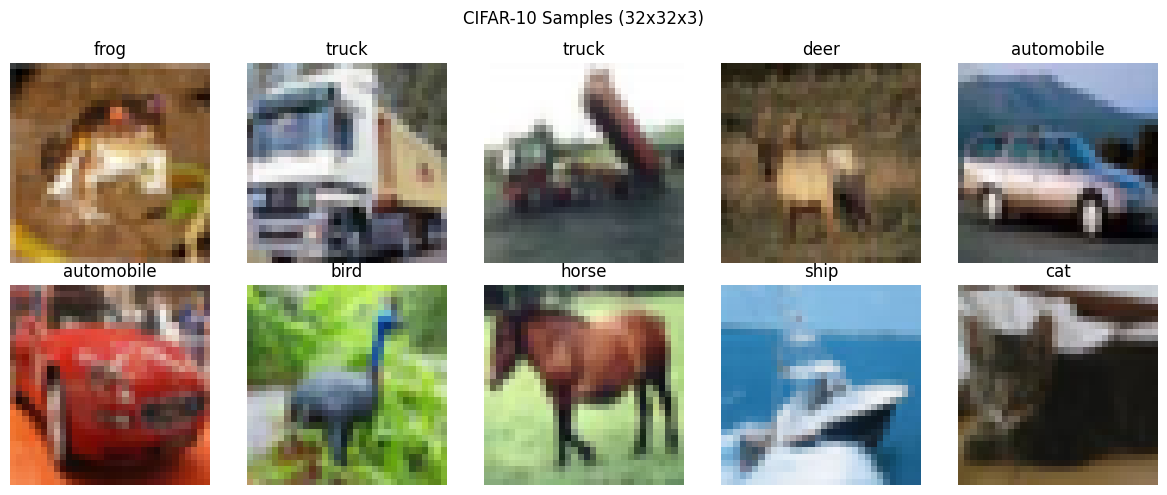

Image shape:       (32, 32, 3)
Training samples:  50000
Number of classes: 10
Output directory:  cifar10_images/training/ (10 subdirectories)


In [10]:
import os, pickle, tarfile, urllib.request, shutil
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

CLASSES = ["airplane", "automobile", "bird", "cat", "deer",
           "dog", "frog", "horse", "ship", "truck"]

CIFAR_URL = "https://www.cs.toronto.edu/~kriz/cifar-10-python.tar.gz"
CIFAR_TAR = "cifar-10-python.tar.gz"

if not os.path.exists(CIFAR_TAR):
    print("Downloading CIFAR-10...")
    urllib.request.urlretrieve(CIFAR_URL, CIFAR_TAR)

with tarfile.open(CIFAR_TAR) as tar:
    tar.extractall(".")

def load_batch(path):
    with open(path, "rb") as f:
        d = pickle.load(f, encoding="bytes")
    return d[b"data"].reshape(-1, 3, 32, 32).transpose(0, 2, 3, 1), d[b"labels"]

train_images, train_labels = [], []
for i in range(1, 6):
    imgs, lbls = load_batch(f"cifar-10-batches-py/data_batch_{i}")
    train_images.append(imgs)
    train_labels.extend(lbls)
train_images = np.concatenate(train_images)
train_labels = np.array(train_labels)

for split, images, labels in [("training", train_images, train_labels)]:
    for cls in CLASSES:
        os.makedirs(f"cifar10_images/{split}/{cls}", exist_ok=True)
    for idx, (img, lbl) in enumerate(zip(images, labels)):
        cls_name = CLASSES[lbl]
        Image.fromarray(img).save(f"cifar10_images/{split}/{cls_name}/{idx:05d}.png")

fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i, ax in enumerate(axes.flat):
    ax.imshow(train_images[i])
    ax.set_title(CLASSES[train_labels[i]])
    ax.axis("off")
plt.suptitle("CIFAR-10 Samples (32x32x3)")
plt.tight_layout()
plt.show()

print(f"Image shape:       {train_images[0].shape}")
print(f"Training samples:  {len(train_images)}")
print(f"Number of classes: {len(CLASSES)}")
print(f"Output directory:  cifar10_images/training/ ({len(CLASSES)} subdirectories)")

## STEP 6 -- CNN Architecture and Transfer Learning (15 min)

Instead of coding a CNN from scratch, we will use SageMaker's **built-in Image Classification** algorithm. Under the hood it uses a pretrained model from TensorFlow Hub (MobileNet V2 by default) and fine-tunes it on our data. This is called **transfer learning**.

**Why transfer learning?**
- Training a CNN from scratch on a small dataset leads to overfitting. A model pretrained on ImageNet (1.2M images, 1,000 classes) has already learned low-level features (edges, textures) and mid-level features (shapes, patterns).
- We freeze or partially freeze the pretrained layers and only retrain the **top classification layer** for our 10 CIFAR-10 classes.
- Result: better accuracy with less data and less training time.

**MobileNet V2 architecture (conceptual):**

| Block | What It Does |
|-------|-------------|
| Input | 224x224x3 image (resized from 32x32 automatically) |
| Depthwise separable convolutions | Lightweight conv blocks that reduce parameters vs. standard Conv2d |
| Inverted residuals | Expand channels, depthwise conv, project back -- with skip connections |
| Global average pooling | Reduces spatial dims to a single vector per channel |
| **Top layer (retrained)** | Dense layer mapping to our 10 classes |

**Key CNN building blocks (same ideas as a from-scratch CNN):**
- **Convolution:** learnable filters slide across the image, extracting local features. Weight sharing makes CNNs parameter-efficient.
- **ReLU:** $f(x) = \max(0, x)$ -- non-linearity after each convolution.
- **Pooling:** downsamples spatial dimensions (MaxPool or Average Pool).
- **Residual / skip connections:** let gradients flow in deep networks.
- **Dropout:** zeros a fraction of activations to reduce overfitting.

> "With the built-in algorithm, you do not write model code. SageMaker provides the pretrained model, the training script, and the container. You just configure hyperparameters and point it at your data."

In [11]:
from sagemaker.core import hyperparameters as hp_module

MODEL_ID = "tensorflow-ic-imagenet-mobilenet-v2-100-224-classification-4"
MODEL_VERSION = "4.0.25"

default_hp = hp_module.retrieve_default(model_id=MODEL_ID, model_version=MODEL_VERSION)

print(f"JumpStart Model: {MODEL_ID}")
print(f"Version:         {MODEL_VERSION}")
print(f"\nDefault hyperparameters:")
for k, v in sorted(default_hp.items()):
    print(f"  {k}: {v}")

[03/27/26 08:47:53] INFO     Found credentials in shared credentials file: ~/.aws/credentials   ]8;id=152;file://C:\Users\CharlesJester\AppData\Roaming\Python\Python312\site-packages\botocore\credentials.py\credentials.py]8;;\:]8;id=230237;file://C:\Users\CharlesJester\AppData\Roaming\Python\Python312\site-packages\botocore\credentials.py#1392\1392]8;;\

JumpStart Model: tensorflow-ic-imagenet-mobilenet-v2-100-224-classification-4
Version:         4.0.25

Default hyperparameters:
  augmentation: False
  augmentation_random_flip: horizontal_and_vertical
  augmentation_random_rotation: 0.2
  augmentation_random_zoom: 0.1
  batch_size: 32
  beta_1: 0.9
  beta_2: 0.999
  binary_mode: False
  dropout_rate: 0.2
  early_stopping: False
  early_stopping_min_delta: 0.0
  early_stopping_patience: 5
  epochs: 5
  epsilon: 1e-07
  eval_metric: accuracy
  image_resize_interpolation: bilinear
  initial_accumulator_value: 0.1
  label_smoothing: 0.1
  learning_rate: 0.001
  momentum: 0.9
  optimizer: adam
  random_seed: 123
  regularizers_l2: 0.0001
  reinitialize_top_layer: Auto
  rho: 0.95
  train_only_top_layer: True
  validation_split_ratio: 0.2


### [BREAK -- 5 min]

---
# STAGE 2 -- SageMaker Training + CNN Training & Augmentation (55 min)

## STEP 7 -- BYOM vs Script Mode (5 min)

**[Conceptual -- whiteboard discussion]**

```
Built-in Algorithms <-----> Script Mode (BYOS) <-----> Bring Your Own Container (BYOM)
   (least control)          (recommended)               (most control)
```

| Approach | You Provide | SageMaker Provides | Best For |
|----------|------------|-------------------|----------|
| Built-in algorithms | Data + hyperparameters | Everything else | Standard problems, no custom code |
| Script Mode (BYOS) | Training script (.py) | Managed container + framework | Custom training with standard frameworks |
| BYOM | Complete Docker image | Compute infrastructure only | Proprietary dependencies or frameworks |

For this curriculum, Script Mode is the right choice. SageMaker has a managed container with scikit-learn pre-installed.

> Ask: "When would you choose BYOM over Script Mode?" (Custom C++ extensions, proprietary frameworks, specific CUDA versions, compliance-mandated base images)

## STEP 8 -- Script Mode Structure (10 min)

Compare the local training script to the Script Mode version. The cell below shows the **local** version for reference.

In [ ]:
# LOCAL VERSION (for comparison -- do not run)
# import pandas as pd
# from sklearn.ensemble import RandomForestClassifier
# from sklearn.metrics import accuracy_score
# import joblib
#
# data = pd.read_csv("data/train.csv")
# X = data.drop("target", axis=1)
# y = data["target"]
#
# model = RandomForestClassifier(n_estimators=100, random_state=42)
# model.fit(X, y)
# print(f"Training accuracy: {accuracy_score(y, model.predict(X)):.4f}")
# joblib.dump(model, "model.pkl")

print("Three things hardcoded: data path, hyperparameters, save location.")
print("Script Mode makes all three flexible via argparse + env vars.")

**Script Mode version** of `train.py` -- three structural changes:
1. `if __name__` guard so SageMaker can import without executing.
2. `argparse` for hyperparameters so SageMaker passes them on the command line.
3. Environment variables for data and model paths.

```python
import argparse
import os
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
import joblib


def main():
    parser = argparse.ArgumentParser()
    parser.add_argument("--n-estimators", type=int, default=100)
    parser.add_argument("--random-state", type=int, default=42)
    args = parser.parse_args()

    train_dir = os.environ.get("SM_CHANNEL_TRAIN", "/opt/ml/input/data/train")
    model_dir = os.environ.get("SM_MODEL_DIR", "/opt/ml/model")

    data = pd.read_csv(os.path.join(train_dir, "train.csv"))
    X = data.drop("target", axis=1)
    y = data["target"]

    model = RandomForestClassifier(
        n_estimators=args.n_estimators,
        random_state=args.random_state,
    )
    model.fit(X, y)

    accuracy = accuracy_score(y, model.predict(X))
    print(f"Training accuracy: {accuracy:.4f}")

    model_path = os.path.join(model_dir, "model.pkl")
    joblib.dump(model, model_path)
    print(f"Model saved to {model_path}")


if __name__ == "__main__":
    main()
```

**Container directory layout:**
```
/opt/ml/
|-- input/
|   +-- data/
|       |-- train/        <- SM_CHANNEL_TRAIN
|       +-- validation/   <- SM_CHANNEL_VALIDATION
|-- model/                <- SM_MODEL_DIR
+-- output/
    +-- failure
```

Run the cell below to write `train.py` to a local `code/` directory. SageMaker will upload this directory to S3 and inject it into the training container.

In [12]:
import os
os.makedirs("code", exist_ok=True)
print("Created code/ directory")

Created code/ directory


In [13]:
%%writefile code/train.py
import argparse
import os
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
import joblib


def main():
    parser = argparse.ArgumentParser()
    parser.add_argument("--n-estimators", type=int, default=100)
    parser.add_argument("--random-state", type=int, default=42)
    args = parser.parse_args()

    train_dir = os.environ.get("SM_CHANNEL_TRAIN", "/opt/ml/input/data/train")
    model_dir = os.environ.get("SM_MODEL_DIR", "/opt/ml/model")

    data = pd.read_csv(os.path.join(train_dir, "train.csv"))
    X = data.drop("target", axis=1)
    y = data["target"]

    model = RandomForestClassifier(
        n_estimators=args.n_estimators,
        random_state=args.random_state,
    )
    model.fit(X, y)

    accuracy = accuracy_score(y, model.predict(X))
    print(f"Training accuracy: {accuracy:.4f}")

    model_path = os.path.join(model_dir, "model.pkl")
    joblib.dump(model, model_path)
    print(f"Model saved to {model_path}")


if __name__ == "__main__":
    main()

Writing code/train.py


### Optional: Run the Training Script in SageMaker Studio

Instead of submitting a managed training job (Step 9), you can run the same logic interactively inside SageMaker Studio. A companion notebook (`sagemaker_studio_train.ipynb`) is provided for this purpose.

**To upload and run it:**

1. In SageMaker Studio (launched in Step 2), click the **Upload** icon in the JupyterLab file browser.
2. Upload `sagemaker_studio_train.ipynb` from the `lectures/` directory.
3. Open the notebook. Select the **Python 3 (Data Science 3.0)** kernel when prompted.
4. Run each cell in order -- it walks through the same training logic as `train.py` but broken into interactive steps: download data from S3, train the model, save artifacts, and upload them back to S3.

The notebook ends with a comparison table showing the tradeoffs between interactive Studio notebooks and managed training jobs.

> **Note:** Studio notebooks keep the instance running (and billing) until you shut down the kernel. Managed training jobs (Step 9) only bill for the duration of the job.

### Windows Line-Ending Fix (required on Windows, skip on Mac/Linux)

SageMaker SDK v3 generates a bootstrap shell script (`sm_train.sh`) that is uploaded to the training container. On Windows, Python writes files with `\r\n` line endings by default, but the Linux container's bash cannot parse `\r`. This causes the training job to fail immediately with `$'\r': command not found`.

Run the cell below **before any training job**. It monkey-patches the `ModelTrainer._prepare_train_script` method in the running kernel so that `sm_train.sh` is written with Unix (`\n`) line endings. Takes effect immediately -- no kernel restart required.

In [23]:
import platform, os, types
from tempfile import TemporaryDirectory

if platform.system() == "Windows":
    from sagemaker.train.model_trainer import ModelTrainer
    from sagemaker.train.constants import TRAIN_SCRIPT
    from sagemaker.train.templates import (
        TRAIN_SCRIPT_TEMPLATE,
        EXECUTE_BASE_COMMANDS,
        EXECUTE_BASIC_SCRIPT_DRIVER,
        EXEUCTE_DISTRIBUTED_DRIVER,
        INSTALL_AUTO_REQUIREMENTS,
        INSTALL_REQUIREMENTS,
    )
    from sagemaker.train.constants import SM_CODE_CONTAINER_PATH

    _orig = ModelTrainer._prepare_train_script

    def _patched_prepare_train_script(self, tmp_dir, source_code, distributed=None):
        """Replacement that writes sm_train.sh with Unix line endings."""
        import logging
        logger = logging.getLogger("sagemaker.train.model_trainer")

        base_command = ""
        if source_code.command:
            if source_code.entry_script:
                logger.warning(
                    "Both 'command' and 'entry_script' are provided in the SourceCode. "
                    "Defaulting to 'command'."
                )
            base_command = " ".join(source_code.command.split())

        install_requirements = ""
        if source_code.requirements:
            if self._jumpstart_config and source_code.requirements == "auto":
                install_requirements = INSTALL_AUTO_REQUIREMENTS
            else:
                install_requirements = INSTALL_REQUIREMENTS.format(
                    requirements_file=source_code.requirements
                )

        working_dir = ""
        if source_code.source_dir:
            working_dir = f"cd {SM_CODE_CONTAINER_PATH} \n"
            if source_code.source_dir.endswith(".tar.gz"):
                tarfile_name = os.path.basename(source_code.source_dir)
                working_dir += f"tar -xzf {tarfile_name} \n"

        if base_command:
            execute_driver = EXECUTE_BASE_COMMANDS.format(base_command=base_command)
        elif distributed:
            execute_driver = EXEUCTE_DISTRIBUTED_DRIVER.format(
                driver_name=distributed.__class__.__name__,
                driver_script=distributed.driver_script,
            )
        elif source_code.entry_script and not source_code.command and not distributed:
            if not source_code.entry_script.endswith((".py", ".sh")):
                raise ValueError(
                    f"Unsupported entry script: {source_code.entry_script}."
                    + "Only .py and .sh scripts are supported."
                )
            execute_driver = EXECUTE_BASIC_SCRIPT_DRIVER
        else:
            raise ValueError(
                f"Unsupported SourceCode or DistributedConfig: {source_code}, {distributed}."
                "Please provide a valid configuration with atleast one of 'command'"
                " or 'entry_script'."
            )

        train_script = TRAIN_SCRIPT_TEMPLATE.format(
            working_dir=working_dir,
            install_requirements=install_requirements,
            execute_driver=execute_driver,
        )

        with open(os.path.join(tmp_dir.name, TRAIN_SCRIPT), "w", newline="\n") as f:
            f.write(train_script)

    ModelTrainer._prepare_train_script = _patched_prepare_train_script
    print("Runtime patch applied -- sm_train.sh will use Unix line endings (no restart needed).")
else:
    print("Not Windows -- no patch needed.")

Runtime patch applied -- sm_train.sh will use Unix line endings (no restart needed).


## STEP 9 -- ModelTrainer Configuration and Training Job Launch (10 min)

Configure the SageMaker `ModelTrainer` (v3 SDK) and launch the training job. In v3, the framework-specific estimators (`SKLearn`, `PyTorch`, etc.) are replaced by a single unified `ModelTrainer` class.

| Console Field | SDK Parameter | Our Value |
|--------------|--------------|----------|
| Training image | `training_image` | sklearn 1.2-1 image via `image_uris.retrieve` |
| IAM role | `role` | Execution role ARN |
| Entry script | `SourceCode.entry_script` | `train.py` |
| Source dir | `SourceCode.source_dir` | `code/` |
| Instance type | Compute config | `ml.m5.large` (cheapest general-purpose) |
| Hyperparameters | `hyperparameters` | `n-estimators=100, random-state=42` |
| S3 output path | `output_data_config` | `s3://.../fraudshield/output/` |

In [24]:
from sagemaker.core.helper.session_helper import Session
from sagemaker.core.image_uris import retrieve
from sagemaker.train import ModelTrainer
from sagemaker.train.configs import SourceCode, Compute

session = Session()
role = SAGEMAKER_ROLE
bucket = session.default_bucket()
region = session.boto_region_name

training_image = retrieve("sklearn", region, version="1.2-1")

trainer = ModelTrainer(
    training_image=training_image,
    source_code=SourceCode(
        source_dir="code/",
        entry_script="train.py",
    ),
    role=role,
    compute=Compute(instance_type="ml.m5.large", instance_count=1),
    hyperparameters={
        "n-estimators": "100",
        "random-state": "42",
    },
    output_data_config={
        "s3_output_path": f"s3://{bucket}/fraudshield/output/",
    },
)

trainer.train(
    input_data_config=[
        {
            "channel_name": "train",
            "data_source": f"s3://{bucket}/fraudshield/data/train/",
        }
    ],
    wait=True,
    logs=True,
)

[03/27/26 10:01:08] INFO     Defaulting to only available Python version: py3                     ]8;id=667141;file://C:\Users\CharlesJester\AppData\Roaming\Python\Python312\site-packages\sagemaker\core\image_uris.py\image_uris.py]8;;\:]8;id=61751;file://C:\Users\CharlesJester\AppData\Roaming\Python\Python312\site-packages\sagemaker\core\image_uris.py#615\615]8;;\

                    INFO     Defaulting to only supported image scope: cpu.                       ]8;id=833028;file://C:\Users\CharlesJester\AppData\Roaming\Python\Python312\site-packages\sagemaker\core\image_uris.py\image_uris.py]8;;\:]8;id=295287;file://C:\Users\CharlesJester\AppData\Roaming\Python\Python312\site-packages\sagemaker\core\image_uris.py#539\539]8;;\

                    INFO     SageMaker session not provided. Using default Session.                  ]8;id=844117;file://C:\Users\CharlesJester\AppData\Roaming\Python\Python312\site-packages\sagemaker\train\defaults.py\defaults.py]8;;\:]8;id=292106;file://C:\Users\CharlesJester\AppData\Roaming\Python\Python312\site-packages\sagemaker\train\defaults.py#61\61]8;;\

                    INFO     Base name not provided. Using default name:                             ]8;id=598517;file://C:\Users\CharlesJester\AppData\Roaming\Python\Python312\site-packages\sagemaker\train\defaults.py\defaults.py]8;;\:]8;id=812292;file://C:\Users\CharlesJester\AppData\Roaming\Python\Python312\site-packages\sagemaker\train\defaults.py#90\90]8;;\
                             sagemaker-scikit-learn-job                                                            

                    INFO     StoppingCondition not provided. Using default:                         ]8;id=241250;file://C:\Users\CharlesJester\AppData\Roaming\Python\Python312\site-packages\sagemaker\train\defaults.py\defaults.py]8;;\:]8;id=516649;file://C:\Users\CharlesJester\AppData\Roaming\Python\Python312\site-packages\sagemaker\train\defaults.py#128\128]8;;\
                             max_runtime_in_seconds=3600 max_wait_time_in_seconds=None                             
                             max_pending_time_in_seconds=None                                                      

...

                    INFO     sagemaker-scikit-learn-job-20260327100108/algo-1-1774623713:        ]8;id=578419;file://C:\Users\CharlesJester\AppData\Roaming\Python\Python312\site-packages\sagemaker\core\resources.py\resources.py]8;;\:]8;id=772812;file://C:\Users\CharlesJester\AppData\Roaming\Python\Python312\site-packages\sagemaker\core\resources.py#35871\35871]8;;\
                             Training accuracy: 1.0000                                                             

                    INFO     sagemaker-scikit-learn-job-20260327100108/algo-1-1774623713:        ]8;id=539093;file://C:\Users\CharlesJester\AppData\Roaming\Python\Python312\site-packages\sagemaker\core\resources.py\resources.py]8;;\:]8;id=265124;file://C:\Users\CharlesJester\AppData\Roaming\Python\Python312\site-packages\sagemaker\core\resources.py#35871\35871]8;;\
                             Model saved to /opt/ml/model/model.pkl                                                

                    INFO     sagemaker-scikit-learn-job-20260327100108/algo-1-1774623713:        ]8;id=127591;file://C:\Users\CharlesJester\AppData\Roaming\Python\Python312\site-packages\sagemaker\core\resources.py\resources.py]8;;\:]8;id=224083;file://C:\Users\CharlesJester\AppData\Roaming\Python\Python312\site-packages\sagemaker\core\resources.py#35871\35871]8;;\
                             Training Container Execution Completed                                                

                    INFO     sagemaker-scikit-learn-job-20260327100108/algo-1-1774623713:        ]8;id=827876;file://C:\Users\CharlesJester\AppData\Roaming\Python\Python312\site-packages\sagemaker\core\resources.py\resources.py]8;;\:]8;id=77871;file://C:\Users\CharlesJester\AppData\Roaming\Python\Python312\site-packages\sagemaker\core\resources.py#35871\35871]8;;\
                             ++ echo 'Training Container Execution Completed'                                      

[03/27/26 10:03:45] INFO     Final Resource Status: Completed                                    ]8;id=889110;file://C:\Users\CharlesJester\AppData\Roaming\Python\Python312\site-packages\sagemaker\core\resources.py\resources.py]8;;\:]8;id=627885;file://C:\Users\CharlesJester\AppData\Roaming\Python\Python312\site-packages\sagemaker\core\resources.py#35874\35874]8;;\

While the job runs (3-7 min), the lifecycle:
1. Provision `ml.m5.large`
2. Pull scikit-learn container from ECR
3. Download training data from S3 into `/opt/ml/input/data/train/`
4. Run `train.py` with hyperparameters as CLI args
5. Compress `/opt/ml/model/` into `model.tar.gz`, upload to S3
6. Stream logs to CloudWatch
7. Tear down instance

You are billed only for steps 1-7.

## STEP 10 -- Preparing Data and Configuring the Built-in Algorithm (10 min)

While the sklearn training job runs, let's prepare the CIFAR-10 images for the built-in algorithm and upload them to S3.

With the built-in Image Classification algorithm, there is **no training script to write**. SageMaker provides:
- The training container (TensorFlow-based)
- The transfer learning script (`transfer_learning.py`)
- The pretrained model weights (MobileNet V2 from ImageNet)

All we configure are hyperparameters and data channels.

In [ ]:
from sagemaker.core.helper.session_helper import Session

session = Session()
bucket = session.default_bucket()

training_s3_uri = session.upload_data(
    path="cifar10_images/training",
    bucket=bucket,
    key_prefix="fraudshield/cifar10/training",
)

print(f"Training data uploaded to: {training_s3_uri}")
print(f"  (50,000 images across 10 class directories)")

In [ ]:
custom_hp = dict(default_hp)
custom_hp["epochs"] = "5"
custom_hp["batch_size"] = "32"
custom_hp["learning_rate"] = "0.001"
custom_hp["augmentation"] = "True"
custom_hp["augmentation_random_flip"] = "horizontal"
custom_hp["augmentation_random_rotation"] = "0.2"
custom_hp["train_only_top_layer"] = "True"

print("Hyperparameters for CIFAR-10 fine-tuning:")
for k, v in sorted(custom_hp.items()):
    print(f"  {k}: {v}")

## STEP 11 -- Data Augmentation (10 min)

With the built-in algorithm, augmentation is controlled entirely through **hyperparameters** -- no code changes needed.

| Hyperparameter | What It Does | Our Setting |
|---------------|-------------|-------------|
| `augmentation` | Master switch for augmentation | `True` |
| `augmentation_random_flip` | Flips images horizontally, vertically, or both | `horizontal` |
| `augmentation_random_rotation` | Max rotation factor (fraction of 2*pi) | `0.2` |
| `augmentation_random_zoom` | Max zoom factor | `0.1` (default) |

The built-in algorithm applies augmentation **only** to training data during fine-tuning. The validation split (controlled by `validation_split_ratio`, default 0.2) is never augmented.

Compare this to a from-scratch approach where you write transform pipelines manually. The built-in algorithm abstracts this into simple hyperparameter toggles.

> Ask: "When would horizontal flip be a bad augmentation choice?" (Digit recognition -- a flipped 6 becomes a 9.)

Residual connections are covered in the CNNs CT (Step 1.6) as a stretch topic. They use skip connections to enable gradient flow in very deep networks.

### Optional: Run CNN Training in SageMaker Studio

A companion notebook (`sagemaker_studio_cnn.ipynb`) is provided in the `lectures/` directory. It contains the full CNN image classification workflow in interactive cells that you can run inside SageMaker Studio:

1. Download and prepare CIFAR-10 data into class directories
2. Upload images to S3
3. Explore the built-in algorithm's default hyperparameters
4. Configure custom hyperparameters (augmentation, transfer learning)
5. Launch the training job and inspect the resulting artifact

**To use it:** Upload `sagemaker_studio_cnn.ipynb` to SageMaker Studio, select the **Python 3 (Data Science 3.0)** kernel, and run cells in order.

> **Reminder:** Shut down the Studio kernel when done to stop billing.

## STEP 11b -- Launch Built-in Image Classification Training (5 min)

Now launch the built-in Image Classification training job. SageMaker retrieves the pretrained MobileNet V2 model from S3, loads our CIFAR-10 images, fine-tunes the top classification layer, and saves the resulting model artifact.

Compare this to the sklearn `ModelTrainer` from Step 9 -- same `Estimator` pattern, but the training script and model are provided by SageMaker instead of written by us.

In [ ]:
from sagemaker.core.helper.session_helper import Session
from sagemaker.core.jumpstart.configs import JumpStartConfig
from sagemaker.train.model_trainer import ModelTrainer
from sagemaker.core.training.configs import InputData

session = Session()
role = SAGEMAKER_ROLE
bucket = session.default_bucket()

js_config = JumpStartConfig(model_id=MODEL_ID, model_version=MODEL_VERSION)

ic_trainer = ModelTrainer.from_jumpstart_config(
    jumpstart_config=js_config,
    hyperparameters=custom_hp,
    role=role,
    sagemaker_session=session,
    output_data_config={"s3_output_path": f"s3://{bucket}/fraudshield/cnn-output/"},
)

print(f"Model:          {MODEL_ID}")
print(f"Training image: {ic_trainer.training_image}")
print(f"Output path:    s3://{bucket}/fraudshield/cnn-output/")
print("Launching built-in Image Classification training...")

ic_trainer.train(
    input_data_config=[
        InputData(channel_name="training", data_source=training_s3_uri),
    ],
    wait=True,
    logs=True,
)

## STEP 12 -- Training Job Anatomy and Artifacts (5 min)

Both training jobs (sklearn Script Mode and built-in Image Classification) follow the same seven-step lifecycle:

| Step | What Happened | sklearn Job (Script Mode) | Image Classification (Built-in) |
|------|--------------|---------------------------|-------------------------------|
| 1. Provisioning | Allocated instance | `ml.m5.large` | `ml.p3.2xlarge` (GPU) |
| 2. Container pull | Pulled framework image from ECR | scikit-learn 1.2-1 | TensorFlow 2.9 |
| 3. Data download | Data into `/opt/ml/input/data/` | `train.csv` from S3 | CIFAR-10 images from S3 |
| 4. Script execution | Ran entry script | Your `train.py` | SageMaker's `transfer_learning.py` |
| 5. Artifact upload | `/opt/ml/model/` -> `model.tar.gz` -> S3 | `model.pkl` | TF SavedModel |
| 6. Logging | stdout/stderr -> CloudWatch | accuracy output | epoch metrics |
| 7. Teardown | Terminated instance | Status: Completed | Status: Completed |

Key difference: with the built-in algorithm, you did not write a training script. SageMaker provided the container, the script, and the pretrained weights.

In [ ]:
print("sklearn (fraud) model artifact:")
print(f"  {trainer.model_data}")
print()
print("Image Classification (CIFAR-10) model artifact:")
print(f"  {ic_trainer.model_data}")
print()
print("Artifact pattern: <output_path>/<job-name>/output/model.tar.gz")
print("This S3 URI is the bridge between Train and Deploy.")

### [BREAK -- 5 min]

---
# STAGE 3 -- Encoder-Decoder Architectures + ML Lifecycle & Cleanup (45 min)

## STEP 13 -- LSTM Primer for Encoder-Decoder (5 min)

**[Conceptual bridge -- just enough for encoder-decoder. Full RNN/LSTM/GRU treatment is Monday.]**

**What an LSTM does:**
- Processes a sequence one step at a time, like reading a sentence word by word.
- Maintains two state vectors:
  - **Hidden state** $h_t$ -- a working summary of the sequence so far.
  - **Cell state** $c_t$ -- a long-term memory highway.
- After processing the entire sequence, the final states $(h_T, c_T)$ summarize the input.

**Why LSTM instead of a simpler recurrence:**
- A basic recurrent cell multiplies gradients by the same weight matrix at every time step, causing gradients to vanish on long sequences.
- LSTMs use **gates** that let gradients flow via addition rather than repeated multiplication.
- Result: LSTMs capture dependencies across dozens or hundreds of time steps.

You do not need the gate equations today. What matters: **LSTM reads a sequence, produces final states that summarize it. The encoder uses this to compress; the decoder uses the encoder's states to generate.**

## STEP 14 -- The Encoder-Decoder Idea (8 min)

**[Conceptual -- draw the architecture]**

So far, our networks produce a single output (classification). Many tasks need **sequence-to-sequence** output: translation, summarization, chatbots.

The **encoder-decoder** architecture:
1. **Encoder:** reads the input sequence, compresses it into a fixed-size context vector (final hidden state).
2. **Decoder:** takes the context vector and generates the output sequence one token at a time.

```
Encoder:  x_1, x_2, ..., x_n --> [LSTM] --> context vector (h_n, c_n)
                                                  |
Decoder:  <SOS> --> [LSTM] --> y_1 --> [LSTM] --> y_2 --> ... --> <EOS>
```

- The context vector is a **bottleneck**: it must capture everything about the input. This limitation motivates **attention mechanisms** (Module 005).
- Today's task: **reversing digit strings** (e.g., `1 2 3 4` -> `4 3 2 1`) to isolate the architecture from language complexity.

## STEP 15 -- Generate Sequence Reversal Data (5 min)

Three sequences per sample:
- **Encoder input:** original digit string, padded.
- **Decoder input:** SOS + reversed digits, padded (teacher forcing).
- **Decoder target:** reversed digits + EOS, padded (what the decoder should predict).

In [ ]:
import numpy as np

PAD_TOKEN = 0
SOS_TOKEN = 11
EOS_TOKEN = 12
NUM_TOKENS = 13
MAX_LEN = 6

def generate_reversal_data(n_samples, max_len=MAX_LEN, seed=42):
    rng = np.random.RandomState(seed)
    encoder_inputs = []
    decoder_inputs = []
    decoder_targets = []

    for _ in range(n_samples):
        length = rng.randint(3, max_len + 1)
        seq = rng.randint(1, 11, size=length).tolist()
        reversed_seq = seq[::-1]

        enc_in = seq + [PAD_TOKEN] * (max_len - length)
        dec_in = [SOS_TOKEN] + reversed_seq + [PAD_TOKEN] * (max_len - length)
        dec_tgt = reversed_seq + [EOS_TOKEN] + [PAD_TOKEN] * (max_len - length)

        encoder_inputs.append(enc_in)
        decoder_inputs.append(dec_in)
        decoder_targets.append(dec_tgt)

    return (np.array(encoder_inputs),
            np.array(decoder_inputs),
            np.array(decoder_targets))

enc_train, dec_in_train, dec_tgt_train = generate_reversal_data(3000, seed=42)
enc_test, dec_in_test, dec_tgt_test = generate_reversal_data(500, seed=99)

print(f"Encoder input shape:  {enc_train.shape}")
print(f"Decoder input shape:  {dec_in_train.shape}")
print(f"Decoder target shape: {dec_tgt_train.shape}")
print(f"\nExample:")
print(f"  Encoder input:  {enc_train[0].tolist()}")
print(f"  Decoder input:  {dec_in_train[0].tolist()}")
print(f"  Decoder target: {dec_tgt_train[0].tolist()}")

## STEP 15 (continued) -- Encoder and Decoder Design

**Encoder:**
```
MODEL Encoder(vocab_size, embed_dim, hidden_dim):
  LAYERS:
    Embedding(vocab_size, embed_dim, padding_idx=PAD_TOKEN)
    LSTM(input_size=embed_dim, hidden_size=hidden_dim)

  FORWARD PASS:
    embedded              <- Embedding(input_sequence)
    all_outputs, (h_n, c_n) <- LSTM(embedded)
    RETURN (h_n, c_n)     # context vector only
```

- Reads input, produces only the final hidden state and cell state.
- `padding_idx=PAD_TOKEN` ensures padding tokens get zero embeddings.

**Decoder:**
```
MODEL Decoder(vocab_size, embed_dim, hidden_dim):
  LAYERS:
    Embedding(vocab_size, embed_dim, padding_idx=PAD_TOKEN)
    LSTM(input_size=embed_dim, hidden_size=hidden_dim)
    FullyConnected(hidden_dim, vocab_size)

  FORWARD PASS:
    embedded                    <- Embedding(decoder_input)
    output, (h_n, c_n)         <- LSTM(embedded, initial_hidden)  # initial_hidden = context vector
    logits                     <- FC(output)
    RETURN logits, (h_n, c_n)
```

- Receives the context vector as its initial hidden state.
- **Teacher forcing** (training): feed the correct previous token at each step.
- **Autoregressive decoding** (inference): feed the model's own predictions back in.

## STEP 16 -- Seq2Seq Assembly and Training Concepts (5 min)

```
MODEL Seq2Seq(encoder, decoder):
  FORWARD PASS:
    context_vector  <- encoder.forward(source_sequence)
    logits, _       <- decoder.forward(target_input, context_vector)
    RETURN logits

INSTANTIATION:
    embed_dim  = 16
    hidden_dim = 64
    encoder  <- Encoder(NUM_TOKENS, embed_dim, hidden_dim)
    decoder  <- Decoder(NUM_TOKENS, embed_dim, hidden_dim)
    seq2seq  <- Seq2Seq(encoder, decoder)
```

The Seq2Seq model is two modules composed together. The encoder compresses; the decoder generates. This pattern is the foundation of modern NLP:
- **GPT** is a decoder.
- **BERT** is an encoder.
- **T5** is an encoder-decoder.

Training uses `CrossEntropyLoss(ignore_index=PAD_TOKEN)` so padding positions do not contribute to the loss. Token-level accuracy is computed on non-padded positions only.

> Ask: "What is the main limitation of compressing the entire input into a single context vector?" (Information bottleneck. Long or complex inputs lose detail. This motivates attention mechanisms in Module 005.)

## STEP 17 -- JumpStart Quick Demo (5 min)

**[Console click-through]**

1. Switch to the Studio browser tab.
2. Navigate to **JumpStart** in the left sidebar (rocket icon).
3. Browse the model catalog. Categories: Text Generation, Image Classification, Tabular, Sentence Embeddings.
4. Select a lightweight model that deploys on `ml.m5.xlarge`.
5. Set endpoint name: `fraudshield-demo-endpoint`. Click **Deploy**.

JumpStart bundles the Model, Endpoint Configuration, and Endpoint creation into one action. In the Deployment module, you will do these three steps manually.

6. Test the endpoint with the sample notebook or explain the invocation pattern.

## STEP 18 -- ML Lifecycle Mapping (5 min)

**[Interactive discussion]**

| Lifecycle Stage | What We Did Today | Console Location |
|----------------|-------------------|------------------|
| **Prepare** | Generated synthetic fraud data, uploaded to S3 | S3, Processing |
| **Build** | Created Studio Domain, explored CNN architecture via JumpStart | Studio, JumpStart |
| **Train & Tune** | Launched sklearn + built-in Image Classification jobs, viewed artifacts | Training jobs |
| **Deploy** | Deployed JumpStart model to endpoint | Inference > Endpoints |
| **Monitor** | (Coming in later modules) | Model monitoring |
| **Govern** | Created IAM execution role | IAM console, Domain settings |

We touched every stage except Monitor.

## STEP 19 -- Mandatory Cleanup (5 min)

**[Console click-through -- EVERY student must complete this]**

1. **Inference > Endpoints** -- select `fraudshield-demo-endpoint` -- Actions -- Delete.
2. **Inference > Models** -- select the associated model -- Actions -- Delete.
3. **Inference > Endpoint configurations** -- select the config -- Actions -- Delete.
4. **S3 console** -- navigate to your default SageMaker bucket -- delete the `fraudshield/` prefix.
5. Check **Billing & Cost Management**.

**Delete order: endpoint first (stops billing immediately), then model, then configuration.**

Walk around the room to verify every student has deleted their endpoint. This is non-negotiable.

---
## Wrap-up & Q&A Buffer (15 min)

**Summary:** Four things accomplished today:
1. Governed SageMaker environment: Studio Domain, IAM execution role, least-privilege concepts.
2. CNN architectures: convolutions exploit spatial structure; transfer learning with built-in algorithms.
3. SageMaker training: Script Mode (sklearn), built-in algorithms (Image Classification), training jobs, S3 artifacts.
4. Encoder-decoder: sequence-to-sequence pattern for translation-style tasks.

**Monday Preview:** RNNs, LSTMs, and GRUs in full detail (the architectures inside the encoder/decoder). SageMaker Deployment (Model Registry, endpoints) and MLOps (pipelines, CI/CD). Read the RNNs and LSTMs & GRUs CTs before Monday.